In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#visualization style
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
print("datasetshape:", df.shape)
print("/nFirst 5 rows:")
df.head()

datasetshape: (891, 12)
/nFirst 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("\nDataset Info:")
print("=" * 50)
df.info()

print("\n\nBasic statistics:")
print("=" * 50)
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Basic statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
print("Missing Values in each column:")
print("="*50)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
})
missing_df[missing_df['Missing Values'] > 0]

Missing Values in each column:


,Missing Values,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


Survival Analysis:
Overall Survival Rate: 38.38%
Overall Death Rate: 61.62%


C:\Users\tmagi\AppData\Local\Temp\ipykernel_9320\2728957528.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, ax=axes[0], palette='Set2')


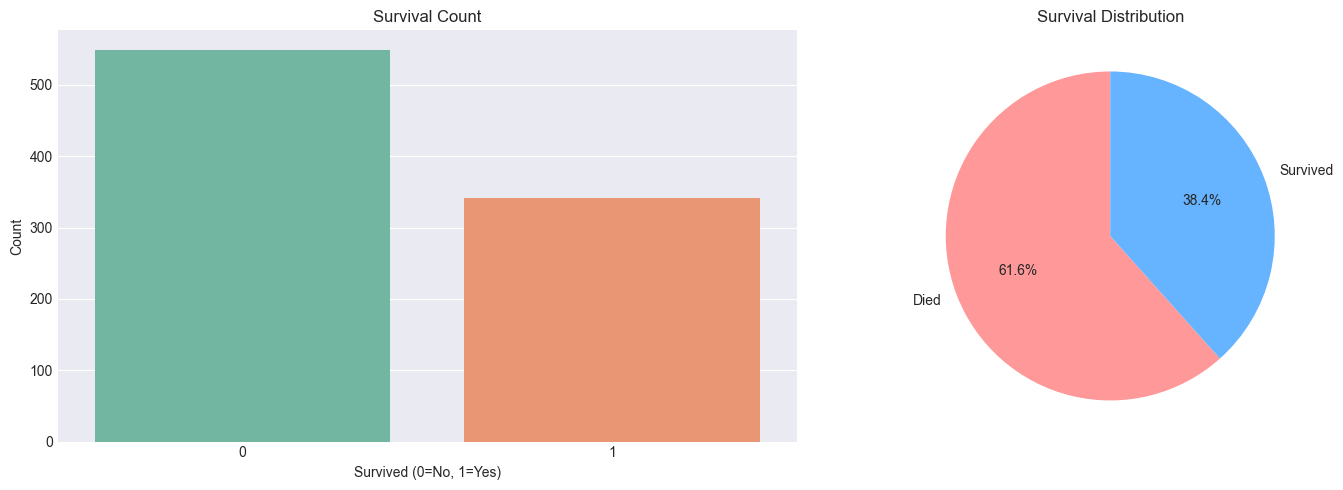

In [5]:
#survival rate
print("Survival Analysis:")
print("="*50)
survival_rate = df['Survived'].value_counts(normalize=True) * 100
print(f"Overall Survival Rate: {survival_rate[1]:.2f}%")
print(f"Overall Death Rate: {survival_rate[0]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#Count plot
sns.countplot(x='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
#Piechart
survival_counts = df['Survived'].value_counts()
axes[1].pie(survival_counts, labels=['Died', 'Survived'], autopct='%1.1f%%', 
           colors=['#ff9999','#66b3ff'], startangle=90)
axes[1].set_title('Survival Distribution')

plt.tight_layout()
plt.show()

Survival by Gender:
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


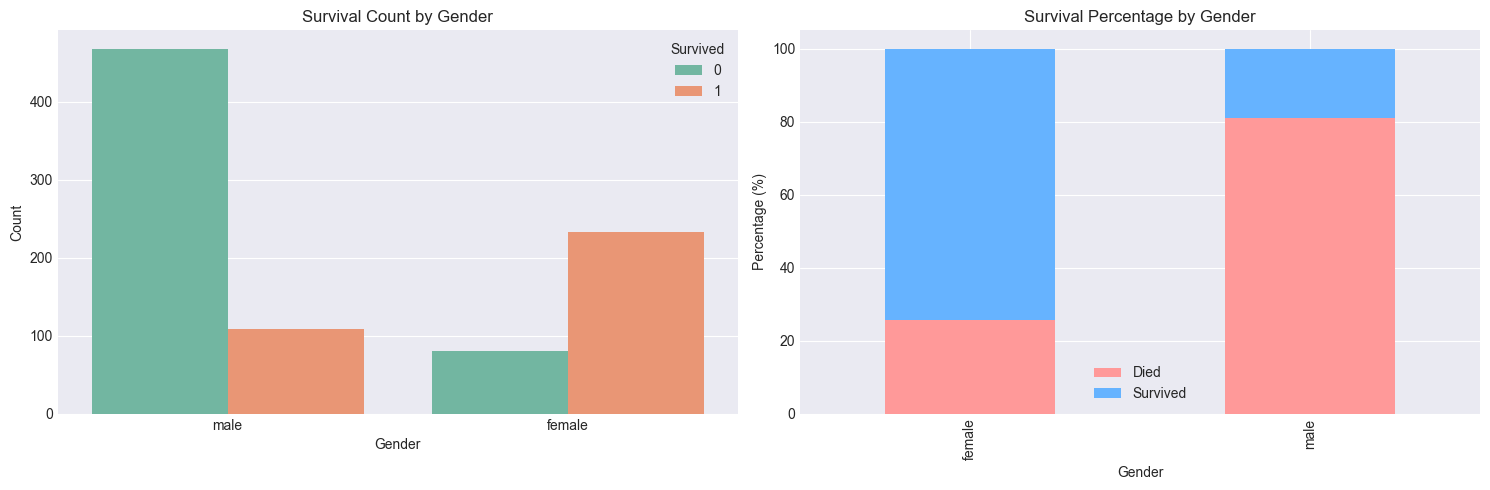

In [6]:
#survival by gender
print("Survival by Gender:")
print("="*50)
gender_survival = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print(gender_survival)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')


#Percentage plot
gender_survival_percent = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
gender_survival_percent.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff9999','#66b3ff'])
axes[1].set_title('Survival Percentage by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

Survival by Passenger Class:
Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


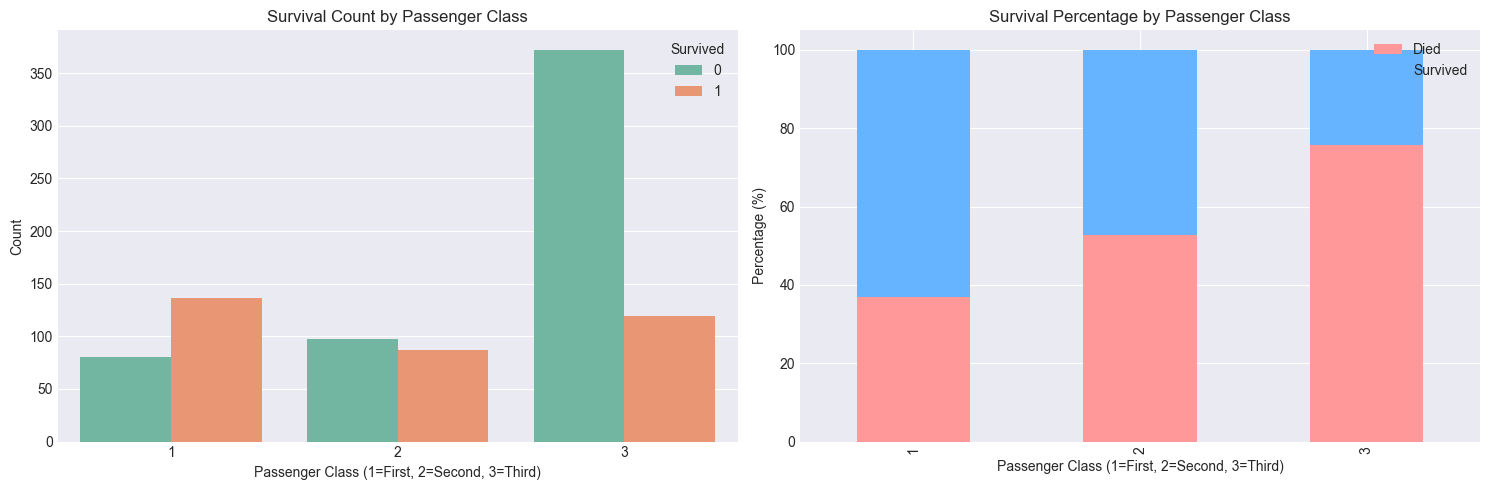

In [7]:
#Survival by passenger class
print("Survival by Passenger Class:")
print("="*50)
class_survival = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
print(class_survival)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count by Passenger Class')
axes[0].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
axes[0].set_ylabel('Count')

#Percentage plot
class_survival.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff9999','#66b3ff'])
axes[1].set_title('Survival Percentage by Passenger Class')
axes[1].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

Age Analysis:
Average Age: 29.70
Median Age: 28.00
Minimum Age: 0.42
Maximum Age: 80.00


C:\Users\tmagi\AppData\Local\Temp\ipykernel_9320\40351313.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1], palette='Set2')


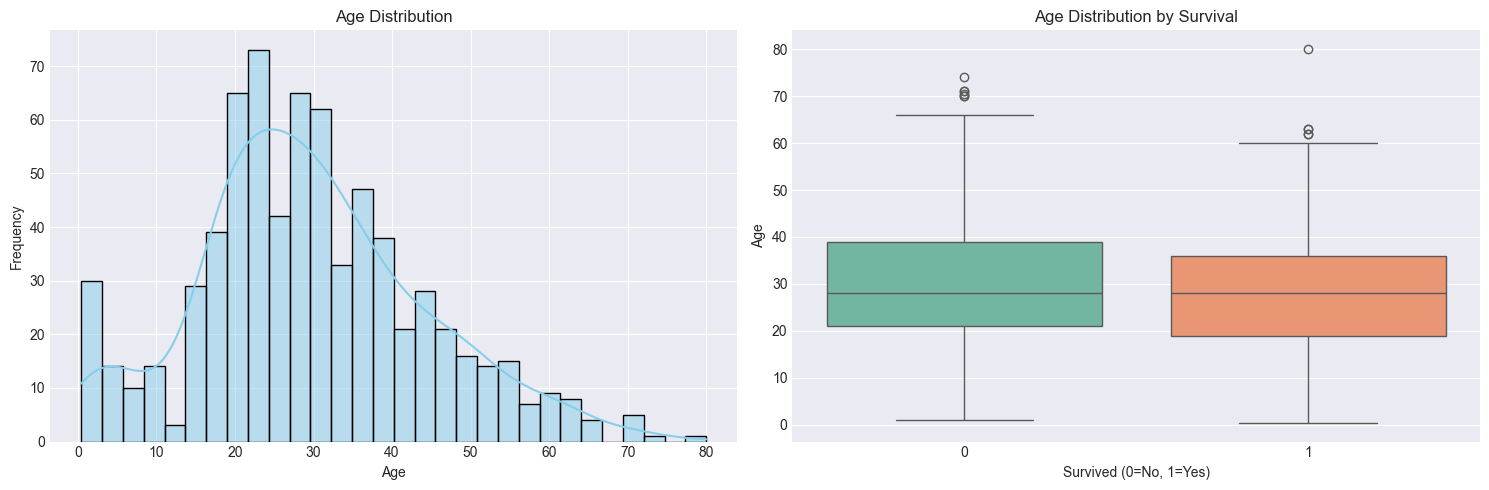

In [8]:
#Age distribution and survival
print("Age Analysis:")
print("="*50)
print(f"Average Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Minimum Age: {df['Age'].min():.2f}")
print(f"Maximum Age: {df['Age'].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Histogram of age
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

#Boxplot of age by survival
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

Survival by Class and Gender:
Survived         0   1
Pclass Sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47


C:\Users\tmagi\AppData\Local\Temp\ipykernel_9320\2796616395.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='Set2', ci=None)


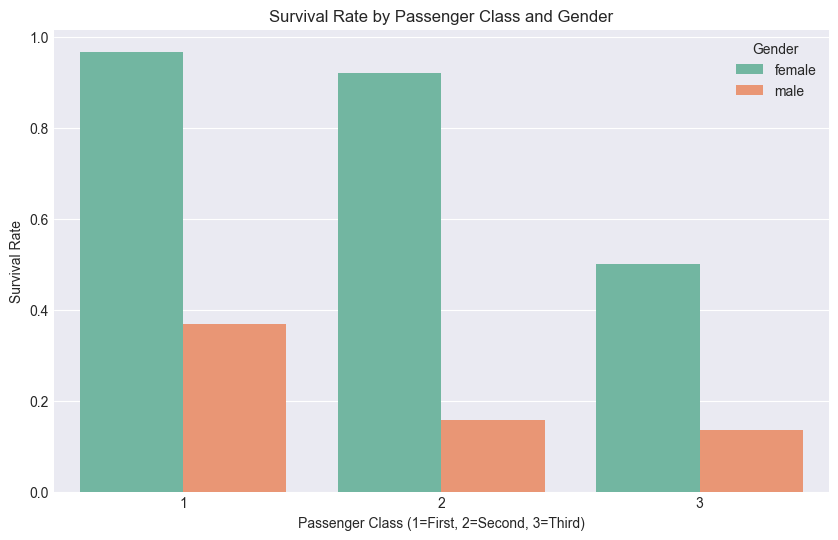

In [9]:
#Survival by Class and Gender
print("Survival by Class and Gender:")
print("="*50)
#pivot table
pivot_table = df.pivot_table(index=['Pclass', 'Sex'], 
                             columns='Survived', 
                             values='PassengerId', 
                             aggfunc='count',
                             fill_value=0)
print(pivot_table)

#Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='Set2', ci=None)
plt.title('Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate')
plt.legend(title='Gender')
plt.show()

Survival by Family Size:
Survived             0          1
FamilySize                       
1            69.646182  30.353818
2            44.720497  55.279503
3            42.156863  57.843137
4            27.586207  72.413793
5            80.000000  20.000000
6            86.363636  13.636364
7            66.666667  33.333333
8           100.000000   0.000000
11          100.000000   0.000000


C:\Users\tmagi\AppData\Local\Temp\ipykernel_9320\2138388554.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='IsAlone', y='Survived', data=df, ax=axes[1], palette='Set2', ci=None)
C:\Users\tmagi\AppData\Local\Temp\ipykernel_9320\2138388554.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IsAlone', y='Survived', data=df, ax=axes[1], palette='Set2', ci=None)
C:\Users\tmagi\AppData\Local\Temp\ipykernel_9320\2138388554.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['With Family', 'Alone'])


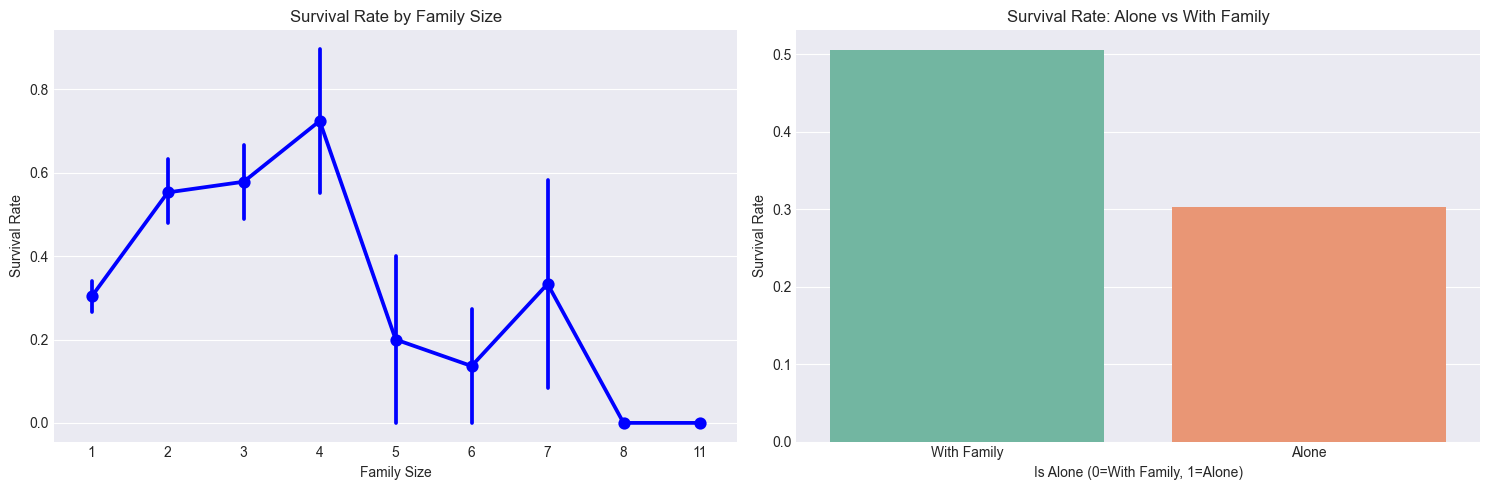

In [10]:
#Family size analysis
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("Survival by Family Size:")
print("="*50)
family_survival = pd.crosstab(df['FamilySize'], df['Survived'], normalize='index') * 100
print(family_survival.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Survival rate
sns.pointplot(x='FamilySize', y='Survived', data=df, ax=axes[0], color='blue')
axes[0].set_title('Survival Rate by Family Size')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate')

#Survival rate for alone vs with family
sns.barplot(x='IsAlone', y='Survived', data=df, ax=axes[1], palette='Set2', ci=None)
axes[1].set_title('Survival Rate: Alone vs With Family')
axes[1].set_xlabel('Is Alone (0=With Family, 1=Alone)')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['With Family', 'Alone'])

plt.tight_layout()
plt.show()

In [11]:
#IsChild
df['IsChild'] = (df['Age'] < 18).astype(int)

#survival for children
child_survival = df.groupby('IsChild')['Survived'].mean() * 100
print("Survival Rate by Age Group:")
print(f"Children (<18): {child_survival[1]:.2f}%")
print(f"Adults (18+): {child_survival[0]:.2f}%")

Survival Rate by Age Group:
Children (<18): 53.98%
Adults (18+): 36.12%


Average Fare - Survivors: $48.40
Average Fare - Non-survivors: $22.12


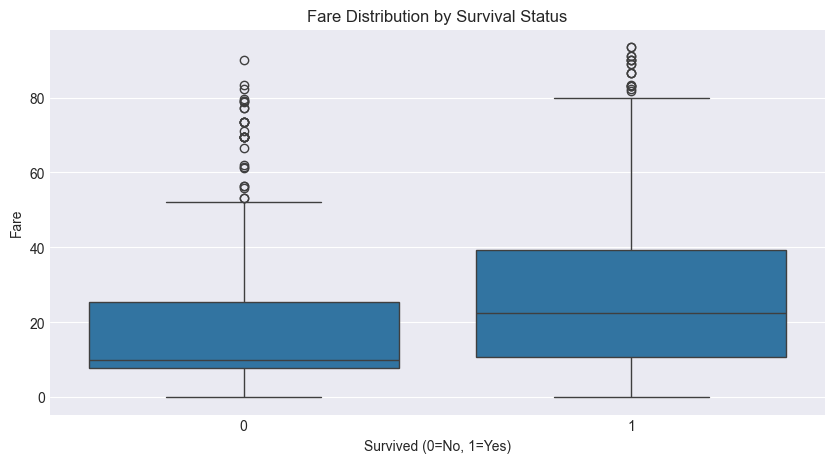

In [12]:
#average fare for survivors vs non-survivors
fare_by_survival = df.groupby('Survived')['Fare'].mean()
print(f"Average Fare - Survivors: ${fare_by_survival[1]:.2f}")
print(f"Average Fare - Non-survivors: ${fare_by_survival[0]:.2f}")

# Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(x='Survived', y='Fare', data=df[df['Fare'] < 100])  # Filter outliers
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare')
plt.show()